In [1]:
%load_ext autoreload
%autoreload 2
import networkx as nx
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import torch

from robin.rl.entities import RobinEnvFactory

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

In [2]:
from robin.supply.constants import EDGE_TYPE_SAME_MARKET, EDGE_TYPE_SAME_AGENT, EDGE_TYPE_DEST_ORIGIN

def report_edge_types(num_nodes: int,edge_type: torch.Tensor):
    edge_count = torch.bincount(edge_type)
    total_edge_count = edge_count.sum()
    print(f'Number of edges of type EDGE_TYPE_SAME_MARKET: {edge_count[EDGE_TYPE_SAME_MARKET]}')
    print(f'Number of edges of type EDGE_TYPE_SAME_AGENT: {edge_count[EDGE_TYPE_SAME_AGENT]}')
    print(f'Number of edges of type EDGE_TYPE_DEST_ORIGIN: {edge_count[EDGE_TYPE_DEST_ORIGIN]}')
    print(f'Total number of edges: {total_edge_count}')

base_env = RobinEnvFactory.create(
    path_config_supply='../configs/rl/supply_data_base.yaml',
    path_config_demand='../configs/rl/demand_data_base.yaml',
    graph=True,
    use_pyg_wrapper=True,
    seed=0
)
print('Base scenario')
num_nodes = base_env.services_graph.x.shape[0]
print(f'Number of nodes: {num_nodes}')
report_edge_types(num_nodes, base_env.services_graph.edge_type)

large_env = RobinEnvFactory.create(
    path_config_supply='../configs/rl/supply_data_large.yaml',
    path_config_demand='../configs/rl/demand_data_large.yaml',
    graph=True,
    use_pyg_wrapper=True,
    seed=0
)
print('\nLarge scenario')
num_nodes = large_env.services_graph.x.shape[0]
print(f'Number of nodes: {num_nodes}')
report_edge_types(num_nodes, large_env.services_graph.edge_type)

Base scenario
Number of nodes: 18
Number of edges of type EDGE_TYPE_SAME_MARKET: 30
Number of edges of type EDGE_TYPE_SAME_AGENT: 90
Number of edges of type EDGE_TYPE_DEST_ORIGIN: 27
Total number of edges: 147

Large scenario
Number of nodes: 63
Number of edges of type EDGE_TYPE_SAME_MARKET: 162
Number of edges of type EDGE_TYPE_SAME_AGENT: 294
Number of edges of type EDGE_TYPE_DEST_ORIGIN: 168
Total number of edges: 624


/tmp/ipykernel_316874/1831276048.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(env.services_graph.edge_index),
/tmp/ipykernel_316874/1831276048.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_type=torch.tensor(env.services_graph.edge_type),
/tmp/ipykernel_316874/1831276048.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(env.services_graph.x)


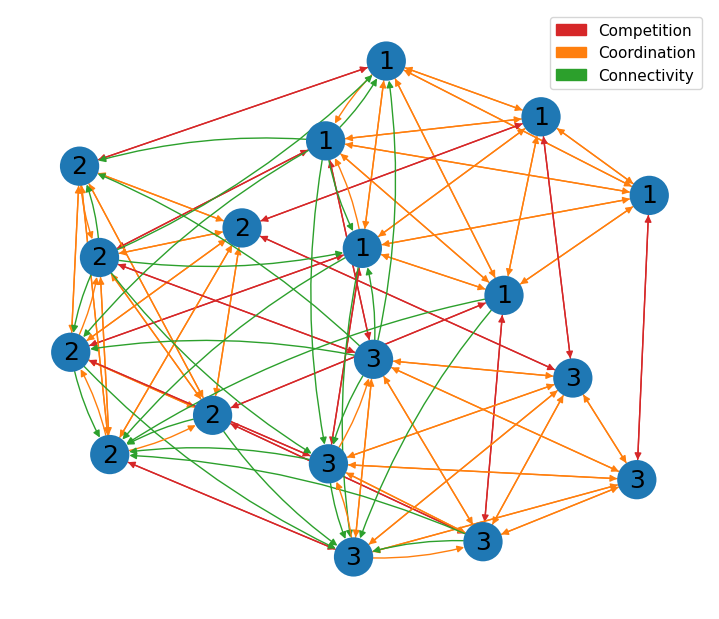

In [3]:
env = RobinEnvFactory.create(
    path_config_supply='../configs/rl/supply_data_base.yaml',
    path_config_demand='../configs/rl/demand_data_base.yaml',
    graph=True,
    use_pyg_wrapper=True,
    seed=0
)
services_graph = Data(
    edge_index=torch.tensor(env.services_graph.edge_index),
    edge_type=torch.tensor(env.services_graph.edge_type),
    x=torch.tensor(env.services_graph.x)
)
graph = to_networkx(services_graph, to_undirected=False, edge_attrs=['edge_type'])
nodes_labels = {idx: f'{service.tsp.id}' for idx, service in enumerate(env.kernel.supply.services)}
edge_colors = ['#d62728', '#ff7f0e', '#2ca02c']  # market, agent, dest-origin

# Build a lookup set of (u, v, type) so we can check for matching reverse edges
edge_type_set = {(u, v, attr) for u, v, attr in graph.edges(data='edge_type')}

# Split edges into symmetric (same type both ways) vs. asymmetric
sym_edges, sym_colors = [], []
asym_edges, asym_colors = [], []
for u, v, attr in graph.edges(data='edge_type'):
    colour = edge_colors[int(attr)]
    if (v, u, attr) in edge_type_set:
        sym_edges.append((u, v))
        sym_colors.append(colour)
    else:
        asym_edges.append((u, v))
        asym_colors.append(colour)

pos = nx.kamada_kawai_layout(graph)
plt.style.use('seaborn-v0_8-pastel')
fig = plt.figure(figsize=(7, 6))
ax = fig.add_axes((0, 0, 1, 1))
ax.set_axis_off()

# Nodes + labels
nx.draw_networkx_nodes(graph, pos=pos, node_size=800, edgecolors='none', ax=ax)
nx.draw_networkx_labels(graph, pos=pos, labels=nodes_labels, font_size=18, ax=ax)

# Edges in two passes, one per connection style
nx.draw_networkx_edges(
    graph, pos=pos, edgelist=sym_edges, edge_color=sym_colors,
    node_size=800, connectionstyle='arc3', ax=ax
)
nx.draw_networkx_edges(
    graph, pos=pos, edgelist=asym_edges, edge_color=asym_colors,
    node_size=800, connectionstyle='arc3,rad=0.1', ax=ax
)

legend_elements = [
    mpatches.Patch(color='#d62728', label='Competition'),
    mpatches.Patch(color='#ff7f0e', label='Coordination'),
    mpatches.Patch(color='#2ca02c', label='Connectivity'),
]
plt.legend(handles=legend_elements, fontsize=11, loc='upper right')
plt.axis('off')
plt.savefig('service_graph_base.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)

/tmp/ipykernel_316874/3359742648.py:9: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_index=torch.tensor(env.services_graph.edge_index),
/tmp/ipykernel_316874/3359742648.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  edge_type=torch.tensor(env.services_graph.edge_type),
/tmp/ipykernel_316874/3359742648.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  x=torch.tensor(env.services_graph.x)


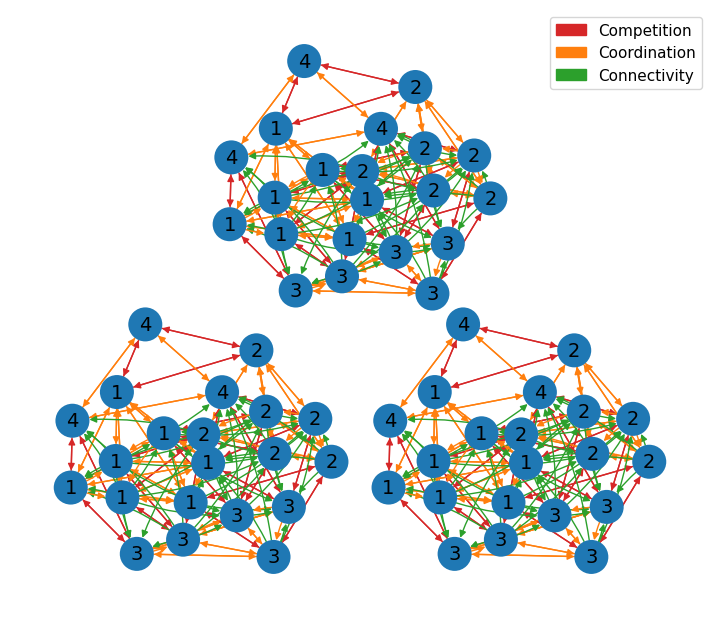

In [4]:
env = RobinEnvFactory.create(
    path_config_supply='../configs/rl/supply_data_large.yaml',
    path_config_demand='../configs/rl/demand_data_large.yaml',
    graph=True,
    use_pyg_wrapper=True,
    seed=0
)
services_graph = Data(
    edge_index=torch.tensor(env.services_graph.edge_index),
    edge_type=torch.tensor(env.services_graph.edge_type),
    x=torch.tensor(env.services_graph.x)
)
graph = to_networkx(services_graph, to_undirected=False, edge_attrs=['edge_type'])
nodes_labels = {idx: f'{service.tsp.id}' for idx, service in enumerate(env.kernel.supply.services)}
edge_colors = ['#d62728', '#ff7f0e', '#2ca02c']  # market, agent, dest-origin

# Build a lookup set of (u, v, type) so we can check for matching reverse edges
edge_type_set = {(u, v, attr) for u, v, attr in graph.edges(data='edge_type')}

# Split edges into symmetric (same type both ways) vs. asymmetric
sym_edges, sym_colors = [], []
asym_edges, asym_colors = [], []
for u, v, attr in graph.edges(data='edge_type'):
    colour = edge_colors[int(attr)]
    if (v, u, attr) in edge_type_set:
        sym_edges.append((u, v))
        sym_colors.append(colour)
    else:
        asym_edges.append((u, v))
        asym_colors.append(colour)

pos = {}
components = list(nx.weakly_connected_components(graph))
offsets = [(0, 0), (2, 0), (1, 2)]  # adjust spacing as needed
for comp, offset in zip(components, offsets):
    subgraph = graph.subgraph(comp)
    sub_pos = nx.kamada_kawai_layout(subgraph)
    for node, p in sub_pos.items():
        pos[node] = (p[0] + offset[0], p[1] + offset[1])
plt.style.use('seaborn-v0_8-pastel')
fig = plt.figure(figsize=(7, 6))
ax = fig.add_axes((0, 0, 1, 1))
ax.set_axis_off()

# Nodes + labels
nx.draw_networkx_nodes(graph, pos=pos, node_size=600, edgecolors='none', ax=ax)
nx.draw_networkx_labels(graph, pos=pos, labels=nodes_labels, font_size=14, ax=ax)

# Edges in two passes, one per connection style
nx.draw_networkx_edges(
    graph, pos=pos, edgelist=sym_edges, edge_color=sym_colors,
    node_size=600, connectionstyle='arc3', ax=ax
)
nx.draw_networkx_edges(
    graph, pos=pos, edgelist=asym_edges, edge_color=asym_colors,
    node_size=600, connectionstyle='arc3,rad=0.1', ax=ax
)

legend_elements = [
    mpatches.Patch(color='#d62728', label='Competition'),
    mpatches.Patch(color='#ff7f0e', label='Coordination'),
    mpatches.Patch(color='#2ca02c', label='Connectivity'),
]
plt.legend(handles=legend_elements, fontsize=11, loc='upper right')
plt.axis('off')
plt.savefig('service_graph_large.pdf', format='pdf', dpi=300, bbox_inches='tight', transparent=True)